### PACOTES

In [9]:
import pandas as pd
import time
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

import plotly.graph_objects as go
from sklearn.manifold import TSNE

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#### INICIO DA MARCACAO DO TEMPO

In [10]:
inicio = time.perf_counter()

### Importar e separar o csv


In [11]:

# Dataset com scores das combinações 3x3
df_scores = pd.read_csv('3x3visu_scores.csv')

# Dataset original
df = pd.read_csv('creditcard.csv')

# PEGAR TOP 5
top_5 = df_scores.nlargest(5, 'Score_Final')

# Lista das features
features_list = top_5['Features'].tolist()

# Lista para armazenar trios
trios_features = []

# MOSTRAR TOP 5
for i, feature in enumerate(features_list, start=1):

    x, y, z = feature.split('|')

    x = x.strip()
    y = y.strip()
    z = z.strip()

    trios_features.append((x, y, z))

    print(f'\n{i}º Feature Completa: {feature}')
    print(f'Variável x{i}: {x}')
    print(f'Variável y{i}: {y}')
    print(f'Variável z{i}: {z}')

print('\nLista final:')
print(trios_features)


1º Feature Completa: V10 | V11 | V14
Variável x1: V10
Variável y1: V11
Variável z1: V14

2º Feature Completa: V10 | V14 | V17
Variável x2: V10
Variável y2: V14
Variável z2: V17

3º Feature Completa: V10 | V14 | V16
Variável x3: V10
Variável y3: V14
Variável z3: V16

4º Feature Completa: V10 | V12 | V14
Variável x4: V10
Variável y4: V12
Variável z4: V14

5º Feature Completa: V3 | V10 | V11
Variável x5: V3
Variável y5: V10
Variável z5: V11

Lista final:
[('V10', 'V11', 'V14'), ('V10', 'V14', 'V17'), ('V10', 'V14', 'V16'), ('V10', 'V12', 'V14'), ('V3', 'V10', 'V11')]


# 1st

### ORIGINAL


In [12]:
posicao_rank = 1
# TARGET COMO STRING
df['status_fraude'] = df['status_fraude'].astype(str)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

# SEPARAR CLASSES
fraudes = df[df['status_fraude'] == '1']
normais = df[df['status_fraude'] == '0']


normais_sample = normais.sample(
    frac=0.10,
    random_state=42
)

print(f'\nFraudes: {len(fraudes)}')
print(f'Normais (10%): {len(normais_sample)}')


fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=normais_sample[x],
        y=normais_sample[y],
        z=normais_sample[z],
        mode='markers',
        name='Normal',
        marker=dict(
            size=1,
            color='blue',
            opacity=0.08
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=fraudes[x],
        y=fraudes[y],
        z=fraudes[z],
        mode='markers',
        name='Fraude',
        marker=dict(
            size=2,
            color='red',
            opacity=0.9
        )
    )
)
# LAYOUT

fig.update_layout(
    title=f'Rank {posicao_rank}: {x} vs {y} vs {z}',
    scene=dict(
        xaxis_title=x,
        yaxis_title=y,
        zaxis_title=z
    ),
    height=800
)

# SALVAR HTML
fig.write_html("1original3x3.html")

print("\nHTML salvo com sucesso.")


Fraudes: 492
Normais (10%): 28432

HTML salvo com sucesso.


#### GMM NA ORIGINAL


Crosstab dos clusters:
status_fraude       0    1
row_0                     
0               12099  435
1              272216   57


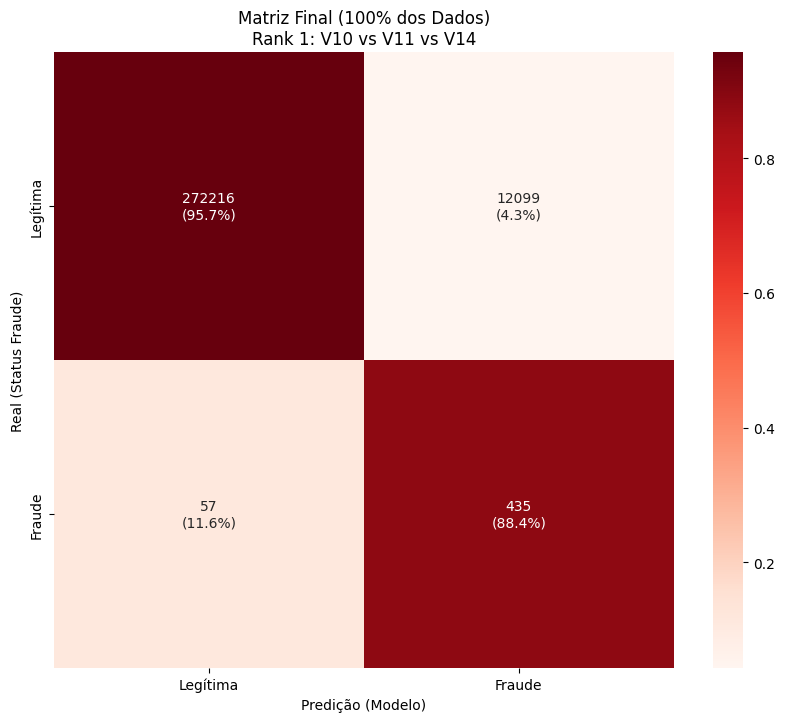


Tempo de execução: 5.2407s
Total de registros analisados: 284807

Features utilizadas:
X: V10
Y: V11
Z: V14

Threshold utilizado: 0.5

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    284315
           1       0.03      0.88      0.07       492

    accuracy                           0.96    284807
   macro avg       0.52      0.92      0.52    284807
weighted avg       1.00      0.96      0.98    284807


AUC-PR: 0.4816


In [13]:
feature_escolhida = features_list[posicao_rank - 1]

x_col, y_col, z_col = [
    f.strip() for f in feature_escolhida.split('|')
]


# BASE DE TREINO
X_bruto = df[[x_col, y_col, z_col]]

# GARANTIR TARGET COMO INTEIRO
y_real = df['status_fraude'].astype(int)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

fim = time.perf_counter()


clusters = gmm.predict(X_scaled)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)

# Cluster com maior quantidade de fraudes
cluster_fraude = ct[1].idxmax()

probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]


threshold = 0.50

y_pred = (probabilidades > threshold).astype(int)


cm = confusion_matrix(y_real, y_pred)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)


labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(cm.flatten(), cm_norm.flatten())
]

labels = np.asarray(labels).reshape(2, 2)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'Matriz Final (100% dos Dados)\n'
    f'Rank {posicao_rank}: {x_col} vs {y_col} vs {z_col}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo de execução: {fim - inicio:.4f}s")

print(f"Total de registros analisados: {len(df)}")

print(f"\nFeatures utilizadas:")
print(f"X: {x_col}")
print(f"Y: {y_col}")
print(f"Z: {z_col}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(y_real, y_pred))

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(
    y_real,
    probabilidades
)

auc_pr = auc(recall_vals, precision_vals)

print(f"\nAUC-PR: {auc_pr:.4f}")


### T-SNE

In [ ]:

# GARANTIR TARGET COMO INT
df['status_fraude'] = df['status_fraude'].astype(int)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# FRAUDES
df_fraude = df[df['status_fraude'] == 1]



df_nao_fraude = df[df['status_fraude'] == 0]

df_nao_fraude_sample = df_nao_fraude.sample(
    frac = 0.10,
    random_state=42
)


# JUNTAR
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)

print(f'\nTotal de registros usados: {len(df_tsne)}')


# FEATURES
X = df_tsne[[x, y, z]]

# PADRONIZAÇÃO
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# t-SNE 3D
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]
df_plot['TSNE_3'] = X_tsne[:, 2]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

# APENAS PARA O PLOTLY
df_plot['status_plot'] = (
    df_plot['status_fraude']
    .astype(str)
)

# GRÁFICO 3D
fig = px.scatter_3d(
    df_plot,
    x='TSNE_1',
    y='TSNE_2',
    z='TSNE_3',
    color='status_plot',
    title=f't-SNE 3D ({x} vs {y} vs {z})',
    color_discrete_map={
        '0': 'blue',
        '1': 'red'
    }
)


# VISUAL
fig.update_traces(
    marker=dict(
        size=3,
        opacity=0.6
    )
)


# SALVAR NO HTML EXISTENTE

novo_grafico = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn'
)

with open("1original3x3.html", "a", encoding="utf-8") as f:

    f.write("<hr>")
    f.write(f"<h2>t-SNE 3D - Rank {posicao_rank}</h2>")
    f.write(novo_grafico)

print("\nGráfico adicionado ao HTML existente.")



RANK ESCOLHIDO: 1
FEATURE: V10 | V11 | V14

Total de registros usados: 28924
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 28924 samples in 0.124s...
[t-SNE] Computed neighbors for 28924 samples in 1.593s...
[t-SNE] Computed conditional probabilities for sample 1000 / 28924
[t-SNE] Computed conditional probabilities for sample 2000 / 28924
[t-SNE] Computed conditional probabilities for sample 3000 / 28924
[t-SNE] Computed conditional probabilities for sample 4000 / 28924
[t-SNE] Computed conditional probabilities for sample 5000 / 28924
[t-SNE] Computed conditional probabilities for sample 6000 / 28924
[t-SNE] Computed conditional probabilities for sample 7000 / 28924
[t-SNE] Computed conditional probabilities for sample 8000 / 28924
[t-SNE] Computed conditional probabilities for sample 9000 / 28924
[t-SNE] Computed conditional probabilities for sample 10000 / 28924
[t-SNE] Computed conditional probabilities for sample 11000 / 28924
[t-SNE] Computed conditional probabiliti

#### GMM NA T-SNE


Formato do t-SNE:
(28924, 3)

Crosstab dos clusters:
status_fraude      0    1
row_0                    
0               9492   27
1              18940  465


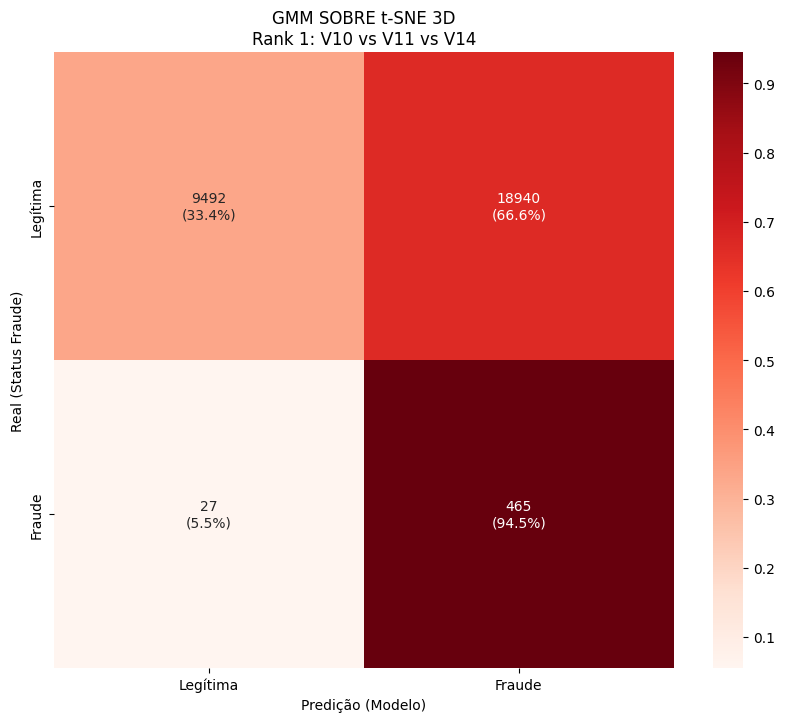


Tempo GMM: 0.1514s
Total analisado: 28924

Threshold utilizado: 0.5

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50     28432
           1       0.02      0.95      0.05       492

    accuracy                           0.34     28924
   macro avg       0.51      0.64      0.27     28924
weighted avg       0.98      0.34      0.49     28924


AUC-PR: 0.2727


In [ ]:
# TARGET REAL
y_real = df_tsne['status_fraude'].astype(int)

# DATAFRAME COM FEATURES t-SNE
X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2', 'TSNE_3']
)

print('\nFormato do t-SNE:')
print(X_tsne_df.shape)

# GMM
inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_tsne_df)

fim = time.perf_counter()


# CLUSTERS
clusters = gmm.predict(X_tsne_df)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)


# CLUSTER FRAUDE
cluster_fraude = ct[1].idxmax()

# PROBABILIDADES

probabilidades = gmm.predict_proba(
    X_tsne_df
)[:, cluster_fraude]

# THRESHOLD
threshold = 0.50

y_pred = (
    probabilidades > threshold
).astype(int)


# MATRIZ DE CONFUSÃO
cm = confusion_matrix(
    y_real,
    y_pred
)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)

# LABELS
labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(
        cm.flatten(),
        cm_norm.flatten()
    )
]

labels = np.asarray(labels).reshape(2, 2)


# HEATMAP
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'GMM SOBRE t-SNE 3D\n'
    f'Rank {posicao_rank}: {x} vs {y} vs {z}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo GMM: {fim - inicio:.4f}s")

print(f"Total analisado: {len(X_tsne_df)}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(
    y_real,
    y_pred
))


# AUC-PR
precision_vals, recall_vals, _ = (
    precision_recall_curve(
        y_real,
        probabilidades
    )
)

auc_pr = auc(
    recall_vals,
    precision_vals
)

print(f"\nAUC-PR: {auc_pr:.4f}")

# 2st

### ORIGINAL

In [ ]:
posicao_rank = 2
# TARGET COMO STRING
df['status_fraude'] = df['status_fraude'].astype(str)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

# SEPARAR CLASSES
fraudes = df[df['status_fraude'] == '1']
normais = df[df['status_fraude'] == '0']


normais_sample = normais.sample(
    frac=0.10,
    random_state=42
)

print(f'\nFraudes: {len(fraudes)}')
print(f'Normais (10%): {len(normais_sample)}')


fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=normais_sample[x],
        y=normais_sample[y],
        z=normais_sample[z],
        mode='markers',
        name='Normal',
        marker=dict(
            size=1,
            color='blue',
            opacity=0.08
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=fraudes[x],
        y=fraudes[y],
        z=fraudes[z],
        mode='markers',
        name='Fraude',
        marker=dict(
            size=2,
            color='red',
            opacity=0.9
        )
    )
)
# LAYOUT

fig.update_layout(
    title=f'Rank {posicao_rank}: {x} vs {y} vs {z}',
    scene=dict(
        xaxis_title=x,
        yaxis_title=y,
        zaxis_title=z
    ),
    height=800
)

# SALVAR HTML
fig.write_html("2original3x3.html")

print("\nHTML salvo com sucesso.")

#### GMM NA ORIGINAL

In [ ]:
feature_escolhida = features_list[posicao_rank - 1]

x_col, y_col, z_col = [
    f.strip() for f in feature_escolhida.split('|')
]


# BASE DE TREINO
X_bruto = df[[x_col, y_col, z_col]]

# GARANTIR TARGET COMO INTEIRO
y_real = df['status_fraude'].astype(int)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

fim = time.perf_counter()


clusters = gmm.predict(X_scaled)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)

# Cluster com maior quantidade de fraudes
cluster_fraude = ct[1].idxmax()

probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]


threshold = 0.50

y_pred = (probabilidades > threshold).astype(int)


cm = confusion_matrix(y_real, y_pred)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)


labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(cm.flatten(), cm_norm.flatten())
]

labels = np.asarray(labels).reshape(2, 2)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'Matriz Final (100% dos Dados)\n'
    f'Rank {posicao_rank}: {x_col} vs {y_col} vs {z_col}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo de execução: {fim - inicio:.4f}s")

print(f"Total de registros analisados: {len(df)}")

print(f"\nFeatures utilizadas:")
print(f"X: {x_col}")
print(f"Y: {y_col}")
print(f"Z: {z_col}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(y_real, y_pred))

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(
    y_real,
    probabilidades
)

auc_pr = auc(recall_vals, precision_vals)

print(f"\nAUC-PR: {auc_pr:.4f}")


### T-SNE

In [ ]:

# GARANTIR TARGET COMO INT
df['status_fraude'] = df['status_fraude'].astype(int)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# FRAUDES
df_fraude = df[df['status_fraude'] == 1]



df_nao_fraude = df[df['status_fraude'] == 0]

df_nao_fraude_sample = df_nao_fraude.sample(
    frac = 0.10,
    random_state=42
)


# JUNTAR
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)

print(f'\nTotal de registros usados: {len(df_tsne)}')


# FEATURES
X = df_tsne[[x, y, z]]

# PADRONIZAÇÃO
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# t-SNE 3D
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]
df_plot['TSNE_3'] = X_tsne[:, 2]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

# APENAS PARA O PLOTLY
df_plot['status_plot'] = (
    df_plot['status_fraude']
    .astype(str)
)

# GRÁFICO 3D
fig = px.scatter_3d(
    df_plot,
    x='TSNE_1',
    y='TSNE_2',
    z='TSNE_3',
    color='status_plot',
    title=f't-SNE 3D ({x} vs {y} vs {z})',
    color_discrete_map={
        '0': 'blue',
        '1': 'red'
    }
)


# VISUAL
fig.update_traces(
    marker=dict(
        size=3,
        opacity=0.6
    )
)


# SALVAR NO HTML EXISTENTE

novo_grafico = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn'
)

with open("2original3x3.html", "a", encoding="utf-8") as f:

    f.write("<hr>")
    f.write(f"<h2>t-SNE 3D - Rank {posicao_rank}</h2>")
    f.write(novo_grafico)

print("\nGráfico adicionado ao HTML existente.")

#### GMM NA T-SNE

In [ ]:
# TARGET REAL
y_real = df_tsne['status_fraude'].astype(int)

# DATAFRAME COM FEATURES t-SNE
X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2', 'TSNE_3']
)

print('\nFormato do t-SNE:')
print(X_tsne_df.shape)

# GMM
inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_tsne_df)

fim = time.perf_counter()


# CLUSTERS
clusters = gmm.predict(X_tsne_df)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)


# CLUSTER FRAUDE
cluster_fraude = ct[1].idxmax()

# PROBABILIDADES

probabilidades = gmm.predict_proba(
    X_tsne_df
)[:, cluster_fraude]

# THRESHOLD
threshold = 0.50

y_pred = (
    probabilidades > threshold
).astype(int)


# MATRIZ DE CONFUSÃO
cm = confusion_matrix(
    y_real,
    y_pred
)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)

# LABELS
labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(
        cm.flatten(),
        cm_norm.flatten()
    )
]

labels = np.asarray(labels).reshape(2, 2)


# HEATMAP
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'GMM SOBRE t-SNE 3D\n'
    f'Rank {posicao_rank}: {x} vs {y} vs {z}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo GMM: {fim - inicio:.4f}s")

print(f"Total analisado: {len(X_tsne_df)}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(
    y_real,
    y_pred
))


# AUC-PR
precision_vals, recall_vals, _ = (
    precision_recall_curve(
        y_real,
        probabilidades
    )
)

auc_pr = auc(
    recall_vals,
    precision_vals
)

print(f"\nAUC-PR: {auc_pr:.4f}")

# 3st

### ORIGINAL

In [ ]:
posicao_rank = 3
# TARGET COMO STRING
df['status_fraude'] = df['status_fraude'].astype(str)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

# SEPARAR CLASSES
fraudes = df[df['status_fraude'] == '1']
normais = df[df['status_fraude'] == '0']


normais_sample = normais.sample(
    frac=0.10,
    random_state=42
)

print(f'\nFraudes: {len(fraudes)}')
print(f'Normais (10%): {len(normais_sample)}')


fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=normais_sample[x],
        y=normais_sample[y],
        z=normais_sample[z],
        mode='markers',
        name='Normal',
        marker=dict(
            size=1,
            color='blue',
            opacity=0.08
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=fraudes[x],
        y=fraudes[y],
        z=fraudes[z],
        mode='markers',
        name='Fraude',
        marker=dict(
            size=2,
            color='red',
            opacity=0.9
        )
    )
)
# LAYOUT

fig.update_layout(
    title=f'Rank {posicao_rank}: {x} vs {y} vs {z}',
    scene=dict(
        xaxis_title=x,
        yaxis_title=y,
        zaxis_title=z
    ),
    height=800
)

# SALVAR HTML
fig.write_html("3original3x3.html")

print("\nHTML salvo com sucesso.")

#### GMM NA ORIGINAL

In [ ]:
feature_escolhida = features_list[posicao_rank - 1]

x_col, y_col, z_col = [
    f.strip() for f in feature_escolhida.split('|')
]


# BASE DE TREINO
X_bruto = df[[x_col, y_col, z_col]]

# GARANTIR TARGET COMO INTEIRO
y_real = df['status_fraude'].astype(int)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

fim = time.perf_counter()


clusters = gmm.predict(X_scaled)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)

# Cluster com maior quantidade de fraudes
cluster_fraude = ct[1].idxmax()

probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]


threshold = 0.50

y_pred = (probabilidades > threshold).astype(int)


cm = confusion_matrix(y_real, y_pred)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)


labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(cm.flatten(), cm_norm.flatten())
]

labels = np.asarray(labels).reshape(2, 2)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'Matriz Final (100% dos Dados)\n'
    f'Rank {posicao_rank}: {x_col} vs {y_col} vs {z_col}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo de execução: {fim - inicio:.4f}s")

print(f"Total de registros analisados: {len(df)}")

print(f"\nFeatures utilizadas:")
print(f"X: {x_col}")
print(f"Y: {y_col}")
print(f"Z: {z_col}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(y_real, y_pred))

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(
    y_real,
    probabilidades
)

auc_pr = auc(recall_vals, precision_vals)

print(f"\nAUC-PR: {auc_pr:.4f}")


### T-SNE

In [ ]:

# GARANTIR TARGET COMO INT
df['status_fraude'] = df['status_fraude'].astype(int)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# FRAUDES
df_fraude = df[df['status_fraude'] == 1]



df_nao_fraude = df[df['status_fraude'] == 0]

df_nao_fraude_sample = df_nao_fraude.sample(
    frac = 0.10,
    random_state=42
)


# JUNTAR
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)

print(f'\nTotal de registros usados: {len(df_tsne)}')


# FEATURES
X = df_tsne[[x, y, z]]

# PADRONIZAÇÃO
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# t-SNE 3D
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]
df_plot['TSNE_3'] = X_tsne[:, 2]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

# APENAS PARA O PLOTLY
df_plot['status_plot'] = (
    df_plot['status_fraude']
    .astype(str)
)

# GRÁFICO 3D
fig = px.scatter_3d(
    df_plot,
    x='TSNE_1',
    y='TSNE_2',
    z='TSNE_3',
    color='status_plot',
    title=f't-SNE 3D ({x} vs {y} vs {z})',
    color_discrete_map={
        '0': 'blue',
        '1': 'red'
    }
)


# VISUAL
fig.update_traces(
    marker=dict(
        size=3,
        opacity=0.6
    )
)


# SALVAR NO HTML EXISTENTE

novo_grafico = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn'
)

with open("3original3x3.html", "a", encoding="utf-8") as f:

    f.write("<hr>")
    f.write(f"<h2>t-SNE 3D - Rank {posicao_rank}</h2>")
    f.write(novo_grafico)

print("\nGráfico adicionado ao HTML existente.")

#### GMM NA T-SNE

In [ ]:
# TARGET REAL
y_real = df_tsne['status_fraude'].astype(int)

# DATAFRAME COM FEATURES t-SNE
X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2', 'TSNE_3']
)

print('\nFormato do t-SNE:')
print(X_tsne_df.shape)

# GMM
inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_tsne_df)

fim = time.perf_counter()


# CLUSTERS
clusters = gmm.predict(X_tsne_df)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)


# CLUSTER FRAUDE
cluster_fraude = ct[1].idxmax()

# PROBABILIDADES

probabilidades = gmm.predict_proba(
    X_tsne_df
)[:, cluster_fraude]

# THRESHOLD
threshold = 0.50

y_pred = (
    probabilidades > threshold
).astype(int)


# MATRIZ DE CONFUSÃO
cm = confusion_matrix(
    y_real,
    y_pred
)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)

# LABELS
labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(
        cm.flatten(),
        cm_norm.flatten()
    )
]

labels = np.asarray(labels).reshape(2, 2)


# HEATMAP
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'GMM SOBRE t-SNE 3D\n'
    f'Rank {posicao_rank}: {x} vs {y} vs {z}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo GMM: {fim - inicio:.4f}s")

print(f"Total analisado: {len(X_tsne_df)}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(
    y_real,
    y_pred
))


# AUC-PR
precision_vals, recall_vals, _ = (
    precision_recall_curve(
        y_real,
        probabilidades
    )
)

auc_pr = auc(
    recall_vals,
    precision_vals
)

print(f"\nAUC-PR: {auc_pr:.4f}")

# 4st

### ORIGINAL

In [ ]:
posicao_rank = 4
# TARGET COMO STRING
df['status_fraude'] = df['status_fraude'].astype(str)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

# SEPARAR CLASSES
fraudes = df[df['status_fraude'] == '1']
normais = df[df['status_fraude'] == '0']


normais_sample = normais.sample(
    frac=0.10,
    random_state=42
)

print(f'\nFraudes: {len(fraudes)}')
print(f'Normais (10%): {len(normais_sample)}')


fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=normais_sample[x],
        y=normais_sample[y],
        z=normais_sample[z],
        mode='markers',
        name='Normal',
        marker=dict(
            size=1,
            color='blue',
            opacity=0.08
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=fraudes[x],
        y=fraudes[y],
        z=fraudes[z],
        mode='markers',
        name='Fraude',
        marker=dict(
            size=2,
            color='red',
            opacity=0.9
        )
    )
)
# LAYOUT

fig.update_layout(
    title=f'Rank {posicao_rank}: {x} vs {y} vs {z}',
    scene=dict(
        xaxis_title=x,
        yaxis_title=y,
        zaxis_title=z
    ),
    height=800
)

# SALVAR HTML
fig.write_html("4original3x3.html")

print("\nHTML salvo com sucesso.")

#### GMM NA ORIGINAL

In [ ]:
feature_escolhida = features_list[posicao_rank - 1]

x_col, y_col, z_col = [
    f.strip() for f in feature_escolhida.split('|')
]


# BASE DE TREINO
X_bruto = df[[x_col, y_col, z_col]]

# GARANTIR TARGET COMO INTEIRO
y_real = df['status_fraude'].astype(int)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

fim = time.perf_counter()


clusters = gmm.predict(X_scaled)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)

# Cluster com maior quantidade de fraudes
cluster_fraude = ct[1].idxmax()

probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]


threshold = 0.50

y_pred = (probabilidades > threshold).astype(int)


cm = confusion_matrix(y_real, y_pred)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)


labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(cm.flatten(), cm_norm.flatten())
]

labels = np.asarray(labels).reshape(2, 2)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'Matriz Final (100% dos Dados)\n'
    f'Rank {posicao_rank}: {x_col} vs {y_col} vs {z_col}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo de execução: {fim - inicio:.4f}s")

print(f"Total de registros analisados: {len(df)}")

print(f"\nFeatures utilizadas:")
print(f"X: {x_col}")
print(f"Y: {y_col}")
print(f"Z: {z_col}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(y_real, y_pred))

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(
    y_real,
    probabilidades
)

auc_pr = auc(recall_vals, precision_vals)

print(f"\nAUC-PR: {auc_pr:.4f}")


### T-SNE

In [ ]:

# GARANTIR TARGET COMO INT
df['status_fraude'] = df['status_fraude'].astype(int)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# FRAUDES
df_fraude = df[df['status_fraude'] == 1]



df_nao_fraude = df[df['status_fraude'] == 0]

df_nao_fraude_sample = df_nao_fraude.sample(
    frac = 0.10,
    random_state=42
)


# JUNTAR
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)

print(f'\nTotal de registros usados: {len(df_tsne)}')


# FEATURES
X = df_tsne[[x, y, z]]

# PADRONIZAÇÃO
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# t-SNE 3D
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]
df_plot['TSNE_3'] = X_tsne[:, 2]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

# APENAS PARA O PLOTLY
df_plot['status_plot'] = (
    df_plot['status_fraude']
    .astype(str)
)

# GRÁFICO 3D
fig = px.scatter_3d(
    df_plot,
    x='TSNE_1',
    y='TSNE_2',
    z='TSNE_3',
    color='status_plot',
    title=f't-SNE 3D ({x} vs {y} vs {z})',
    color_discrete_map={
        '0': 'blue',
        '1': 'red'
    }
)


# VISUAL
fig.update_traces(
    marker=dict(
        size=3,
        opacity=0.6
    )
)


# SALVAR NO HTML EXISTENTE

novo_grafico = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn'
)

with open("4original3x3.html", "a", encoding="utf-8") as f:

    f.write("<hr>")
    f.write(f"<h2>t-SNE 3D - Rank {posicao_rank}</h2>")
    f.write(novo_grafico)

print("\nGráfico adicionado ao HTML existente.")

#### GMM NA T-SNE

In [ ]:
# TARGET REAL
y_real = df_tsne['status_fraude'].astype(int)

# DATAFRAME COM FEATURES t-SNE
X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2', 'TSNE_3']
)

print('\nFormato do t-SNE:')
print(X_tsne_df.shape)

# GMM
inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_tsne_df)

fim = time.perf_counter()


# CLUSTERS
clusters = gmm.predict(X_tsne_df)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)


# CLUSTER FRAUDE
cluster_fraude = ct[1].idxmax()

# PROBABILIDADES

probabilidades = gmm.predict_proba(
    X_tsne_df
)[:, cluster_fraude]

# THRESHOLD
threshold = 0.50

y_pred = (
    probabilidades > threshold
).astype(int)


# MATRIZ DE CONFUSÃO
cm = confusion_matrix(
    y_real,
    y_pred
)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)

# LABELS
labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(
        cm.flatten(),
        cm_norm.flatten()
    )
]

labels = np.asarray(labels).reshape(2, 2)


# HEATMAP
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'GMM SOBRE t-SNE 3D\n'
    f'Rank {posicao_rank}: {x} vs {y} vs {z}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo GMM: {fim - inicio:.4f}s")

print(f"Total analisado: {len(X_tsne_df)}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(
    y_real,
    y_pred
))


# AUC-PR
precision_vals, recall_vals, _ = (
    precision_recall_curve(
        y_real,
        probabilidades
    )
)

auc_pr = auc(
    recall_vals,
    precision_vals
)

print(f"\nAUC-PR: {auc_pr:.4f}")


# 5st

### ORIGINAL

In [ ]:
posicao_rank = 5
# TARGET COMO STRING
df['status_fraude'] = df['status_fraude'].astype(str)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

# SEPARAR CLASSES
fraudes = df[df['status_fraude'] == '1']
normais = df[df['status_fraude'] == '0']


normais_sample = normais.sample(
    frac=0.10,
    random_state=42
)

print(f'\nFraudes: {len(fraudes)}')
print(f'Normais (10%): {len(normais_sample)}')


fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=normais_sample[x],
        y=normais_sample[y],
        z=normais_sample[z],
        mode='markers',
        name='Normal',
        marker=dict(
            size=1,
            color='blue',
            opacity=0.08
        )
    )
)

fig.add_trace(
    go.Scatter3d(
        x=fraudes[x],
        y=fraudes[y],
        z=fraudes[z],
        mode='markers',
        name='Fraude',
        marker=dict(
            size=2,
            color='red',
            opacity=0.9
        )
    )
)
# LAYOUT

fig.update_layout(
    title=f'Rank {posicao_rank}: {x} vs {y} vs {z}',
    scene=dict(
        xaxis_title=x,
        yaxis_title=y,
        zaxis_title=z
    ),
    height=800
)

# SALVAR HTML
fig.write_html("5original3x3.html")

print("\nHTML salvo com sucesso.")

#### GMM NA ORIGINAL

In [ ]:
feature_escolhida = features_list[posicao_rank - 1]

x_col, y_col, z_col = [
    f.strip() for f in feature_escolhida.split('|')
]


# BASE DE TREINO
X_bruto = df[[x_col, y_col, z_col]]

# GARANTIR TARGET COMO INTEIRO
y_real = df['status_fraude'].astype(int)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bruto)

inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

fim = time.perf_counter()


clusters = gmm.predict(X_scaled)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)

# Cluster com maior quantidade de fraudes
cluster_fraude = ct[1].idxmax()

probabilidades = gmm.predict_proba(X_scaled)[:, cluster_fraude]


threshold = 0.50

y_pred = (probabilidades > threshold).astype(int)


cm = confusion_matrix(y_real, y_pred)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)


labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(cm.flatten(), cm_norm.flatten())
]

labels = np.asarray(labels).reshape(2, 2)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'Matriz Final (100% dos Dados)\n'
    f'Rank {posicao_rank}: {x_col} vs {y_col} vs {z_col}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo de execução: {fim - inicio:.4f}s")

print(f"Total de registros analisados: {len(df)}")

print(f"\nFeatures utilizadas:")
print(f"X: {x_col}")
print(f"Y: {y_col}")
print(f"Z: {z_col}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(y_real, y_pred))

# AUC-PR
precision_vals, recall_vals, _ = precision_recall_curve(
    y_real,
    probabilidades
)

auc_pr = auc(recall_vals, precision_vals)

print(f"\nAUC-PR: {auc_pr:.4f}")


### T-SNE

In [ ]:

# GARANTIR TARGET COMO INT
df['status_fraude'] = df['status_fraude'].astype(int)

# PEGAR FEATURES
feature_escolhida = features_list[posicao_rank - 1]

x, y, z = feature_escolhida.split('|')

x = x.strip()
y = y.strip()
z = z.strip()

print('\n=========================')
print(f'RANK ESCOLHIDO: {posicao_rank}')
print(f'FEATURE: {feature_escolhida}')
print('=========================')


# FRAUDES
df_fraude = df[df['status_fraude'] == 1]



df_nao_fraude = df[df['status_fraude'] == 0]

df_nao_fraude_sample = df_nao_fraude.sample(
    frac = 0.10,
    random_state=42
)


# JUNTAR
df_tsne = pd.concat(
    [df_fraude, df_nao_fraude_sample],
    axis=0
)

print(f'\nTotal de registros usados: {len(df_tsne)}')


# FEATURES
X = df_tsne[[x, y, z]]

# PADRONIZAÇÃO
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# t-SNE 3D
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_scaled)

# DATAFRAME FINAL
df_plot = pd.DataFrame()

df_plot['TSNE_1'] = X_tsne[:, 0]
df_plot['TSNE_2'] = X_tsne[:, 1]
df_plot['TSNE_3'] = X_tsne[:, 2]

df_plot['status_fraude'] = df_tsne['status_fraude'].values

# APENAS PARA O PLOTLY
df_plot['status_plot'] = (
    df_plot['status_fraude']
    .astype(str)
)

# GRÁFICO 3D
fig = px.scatter_3d(
    df_plot,
    x='TSNE_1',
    y='TSNE_2',
    z='TSNE_3',
    color='status_plot',
    title=f't-SNE 3D ({x} vs {y} vs {z})',
    color_discrete_map={
        '0': 'blue',
        '1': 'red'
    }
)


# VISUAL
fig.update_traces(
    marker=dict(
        size=3,
        opacity=0.6
    )
)


# SALVAR NO HTML EXISTENTE

novo_grafico = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn'
)

with open("1original3x3.html", "a", encoding="utf-8") as f:

    f.write("<hr>")
    f.write(f"<h2>t-SNE 5D - Rank {posicao_rank}</h2>")
    f.write(novo_grafico)

print("\nGráfico adicionado ao HTML existente.")

#### GMM NA T-SNE

In [ ]:
# TARGET REAL
y_real = df_tsne['status_fraude'].astype(int)

# DATAFRAME COM FEATURES t-SNE
X_tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2', 'TSNE_3']
)

print('\nFormato do t-SNE:')
print(X_tsne_df.shape)

# GMM
inicio = time.perf_counter()

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_tsne_df)

fim = time.perf_counter()


# CLUSTERS
clusters = gmm.predict(X_tsne_df)

ct = pd.crosstab(clusters, y_real)

print("\nCrosstab dos clusters:")
print(ct)


# CLUSTER FRAUDE
cluster_fraude = ct[1].idxmax()

# PROBABILIDADES

probabilidades = gmm.predict_proba(
    X_tsne_df
)[:, cluster_fraude]

# THRESHOLD
threshold = 0.50

y_pred = (
    probabilidades > threshold
).astype(int)


# MATRIZ DE CONFUSÃO
cm = confusion_matrix(
    y_real,
    y_pred
)

cm_norm = confusion_matrix(
    y_real,
    y_pred,
    normalize='true'
)

# LABELS
labels = [
    f"{int(val)}\n({pct:.1%})"
    for val, pct in zip(
        cm.flatten(),
        cm_norm.flatten()
    )
]

labels = np.asarray(labels).reshape(2, 2)


# HEATMAP
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=labels,
    fmt="",
    cmap='Reds',
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude']
)

plt.title(
    f'GMM SOBRE t-SNE 3D\n'
    f'Rank {posicao_rank}: {x} vs {y} vs {z}'
)

plt.xlabel('Predição (Modelo)')
plt.ylabel('Real (Status Fraude)')

plt.show()

# MÉTRICAS
print(f"\nTempo GMM: {fim - inicio:.4f}s")

print(f"Total analisado: {len(X_tsne_df)}")

print(f"\nThreshold utilizado: {threshold}")

print("\nRelatório de Classificação:")

print(classification_report(
    y_real,
    y_pred
))


# AUC-PR
precision_vals, recall_vals, _ = (
    precision_recall_curve(
        y_real,
        probabilidades
    )
)

auc_pr = auc(
    recall_vals,
    precision_vals
)

print(f"\nAUC-PR: {auc_pr:.4f}")

In [ ]:
fim = time.perf_counter()
print(f"O programa levou {fim - inicio:.4f} segundos para rodar, obrigado.")